---
title: "KDE & Gaussian-mixture CDFs"
short_title: "01 · KDE & mixture CDFs"
subtitle: "Smooth, differentiable, invertible marginal transforms — and how to pick their one knob"
description: >
  Replace the jagged empirical CDF with smooth density estimators: a KDE-based
  CDF and a Gaussian-mixture CDF with closed-form forward and root-find inverse.
  Fit both with rbig and gauss_flows, then choose the bandwidth (KDE) and the
  component count (mixture, via BIC) that avoid under- and over-fitting.
---

(sec-nb-mt-01)=
# 01 — KDE & Gaussian-mixture CDFs

The empirical CDF of [notebook 00](00_ecdf_histograms.ipynb) is consistent but
**jagged** (a staircase, not differentiable) and **tail-blind** (nothing beyond
the data). Both problems vanish if we estimate a *smooth* density and integrate
it into a CDF. Two estimators dominate practice: a **kernel density estimate**
(nonparametric) and a **Gaussian mixture** (parametric) — the latter is the
marginal bijector at the heart of `gauss_flows`.

**What you will see**

- A **KDE-based CDF** Gaussianization (`rbig.KDEGaussianizer`) — smooth where
  the ECDF was a staircase.
- The **Gaussian-mixture CDF** $F(x)=\sum_k\pi_k\Phi(\tfrac{x-\mu_k}{\sigma_k})$:
  closed-form forward, differentiable, invertible by root-find — the workhorse
  `gauss_flows.MixtureGaussianCDF`.
- Choosing the **bandwidth** $h$ (KDE) and the **component count** $K$ (mixture,
  via BIC) — the bias/variance knob of each.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.mixture import GaussianMixture

import gauss_flows as gf
import rbig
from _style import GAUSS_KW, style_ax

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(11)

# A clearly bimodal marginal so the bandwidth / component count matter visibly.
x = np.concatenate([rng.normal(-2.0, 0.5, 3000),
                    rng.normal(1.5, 0.8, 3000)])[:, None]
grid = np.linspace(-5, 5, 500)

## 1. KDE-based CDF

A **kernel density estimate** sums a smooth bump at each sample,

$$
\hat f_h(x) = \frac{1}{nh}\sum_{i=1}^n K\!\Big(\frac{x-x_i}{h}\Big),
\qquad
\hat F_h(x) = \int_{-\infty}^{x}\hat f_h\,,
$$
and with a Gaussian kernel that integral is itself a sum of normal CDFs — so
$\hat F_h$ is smooth and strictly increasing, exactly what the probability
integral transform wants. `rbig.KDEGaussianizer` builds $\Phi^{-1}(\hat F_h(x))$.

KDE Gaussianize: output std = 0.940, round-trip err = 4.99e-13


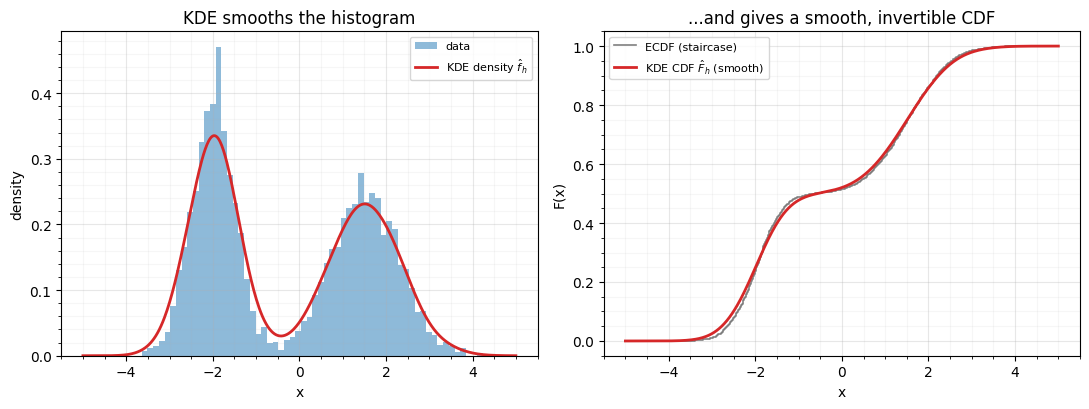

In [2]:
kde = rbig.KDEGaussianizer().fit(x)
z_kde = kde.transform(x)


def ecdf(s, t):
    return np.searchsorted(np.sort(s), t, side="right") / len(s)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(x[:, 0], bins=60, density=True, color="tab:blue", alpha=0.5, label="data")
axes[0].plot(grid, stats.gaussian_kde(x[:, 0])(grid), color="tab:red", lw=2,
             label="KDE density $\\hat f_h$")
axes[0].set(title="KDE smooths the histogram", xlabel="x", ylabel="density")
axes[0].legend(fontsize=8); style_ax(axes[0])

axes[1].step(grid, ecdf(x[:, 0], grid), where="post", color="tab:gray", lw=1.2,
             label="ECDF (staircase)")
axes[1].plot(grid, stats.gaussian_kde(x[:, 0]).integrate_box_1d(-np.inf, grid[0])
             + np.cumsum(stats.gaussian_kde(x[:, 0])(grid)) * (grid[1] - grid[0]),
             color="tab:red", lw=2, label="KDE CDF $\\hat F_h$ (smooth)")
axes[1].set(title="...and gives a smooth, invertible CDF", xlabel="x", ylabel="F(x)")
axes[1].legend(fontsize=8); style_ax(axes[1])
fig.tight_layout()

print(f"KDE Gaussianize: output std = {z_kde.std():.3f}, "
      f"round-trip err = {np.abs(x - kde.inverse_transform(z_kde)).max():.2e}")

The red KDE density traces both modes, and its CDF is the smooth curve the
ECDF staircase was approximating. The Gaussianized output is unit-variance and
round-trips cleanly — no tail blow-up, because the kernel tails extend past the
data automatically.

## 2. The Gaussian-mixture CDF

The parametric workhorse fits a **mixture of $K$ Gaussians** and uses its CDF
directly,

$$
F(x) = \sum_{k=1}^{K}\pi_k\,\Phi\!\Big(\frac{x-\mu_k}{\sigma_k}\Big),
\qquad
z = \Phi^{-1}\big(F(x)\big).
$$

The forward map is a closed-form, differentiable sum; the inverse is the
monotone root-find of [Part 0 notebook 02](../00_foundations/02_forward_vs_inverse.ipynb);
and the log-det is $\log f(x) - \log\phi(z)$. This is `rbig.GMMGaussianizer`
and `gauss_flows.MixtureGaussianCDF` — the marginal layer every parametric
Gaussianization flow stacks.

MixtureGaussianCDF: output std = 0.863, round-trip err = 8.93e-14, log-det finite = True


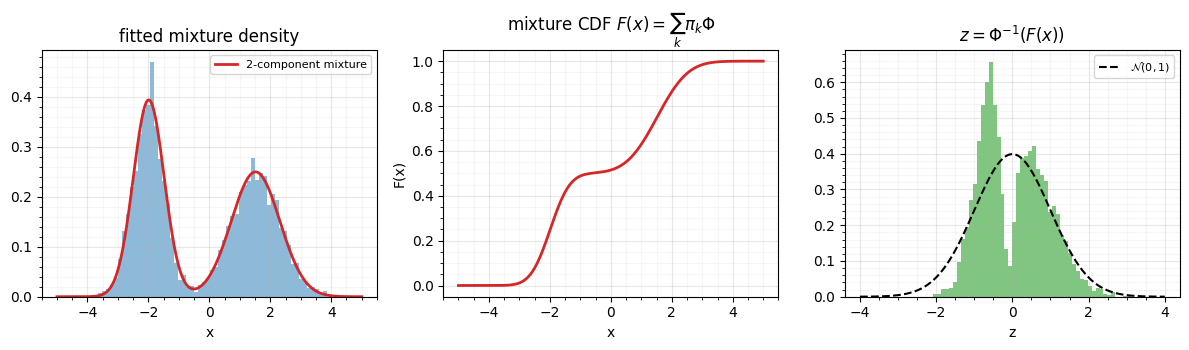

In [3]:
b = gf.MixtureGaussianCDF.from_data(jnp.asarray(x), n_components=2)
z_mix, logdet = jax.vmap(b.transform_and_log_det)(jnp.asarray(x))
x_rt = jax.vmap(b.inverse)(z_mix)

gm = GaussianMixture(2, random_state=0).fit(x)
dens = np.exp(gm.score_samples(grid[:, None]))
cdf = np.array([np.sum(gm.weights_ * stats.norm.cdf(t, gm.means_.ravel(),
                np.sqrt(gm.covariances_.ravel()))) for t in grid])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].hist(x[:, 0], bins=60, density=True, color="tab:blue", alpha=0.5)
axes[0].plot(grid, dens, color="tab:red", lw=2, label="2-component mixture")
axes[0].set(title="fitted mixture density", xlabel="x"); axes[0].legend(fontsize=8)
axes[1].plot(grid, cdf, color="tab:red", lw=2)
axes[1].set(title=r"mixture CDF $F(x)=\sum_k\pi_k\Phi$", xlabel="x", ylabel="F(x)")
zz = np.linspace(-4, 4, 200)
axes[2].hist(np.asarray(z_mix)[:, 0], bins=50, density=True, color="tab:green", alpha=0.6)
axes[2].plot(zz, stats.norm.pdf(zz), **GAUSS_KW, label=r"$\mathcal{N}(0,1)$")
axes[2].set(title=r"$z=\Phi^{-1}(F(x))$", xlabel="z"); axes[2].legend(fontsize=8)
for a in axes:
    style_ax(a)
fig.tight_layout()

print(f"MixtureGaussianCDF: output std = {float(z_mix.std()):.3f}, "
      f"round-trip err = {float(jnp.max(jnp.abs(jnp.asarray(x) - x_rt))):.2e}, "
      f"log-det finite = {bool(jnp.all(jnp.isfinite(logdet)))}")

The two-component mixture nails the bimodal density, its CDF is smooth and
monotone, and the Gaussianized output is a clean standard normal — round-tripping
to ~$10^{-14}$ (the tail-inverse fix from
[gauss_flows#108](https://github.com/jejjohnson/gauss_flows/issues/108)). Unlike
the KDE, the mixture has only $3K$ parameters, is trivially differentiable in
them, and extrapolates sensibly — which is why it is the parametric default.

## 3. Choosing the knob: bandwidth $h$ and components $K$

Each estimator has one capacity knob, and it is the usual bias/variance trade-off.

**KDE bandwidth $h$.** Too small and $\hat f_h$ is a spiky over-fit (high
variance); too large and it smears the two modes into one (high bias). Plug-in
rules like Scott's / Silverman's {cite}`silverman1986density` give a sane default.

BIC by K: {1: 24593, 2: 19821, 3: 19873, 4: 19906, 5: 19939, 6: 19961, 7: 19984}


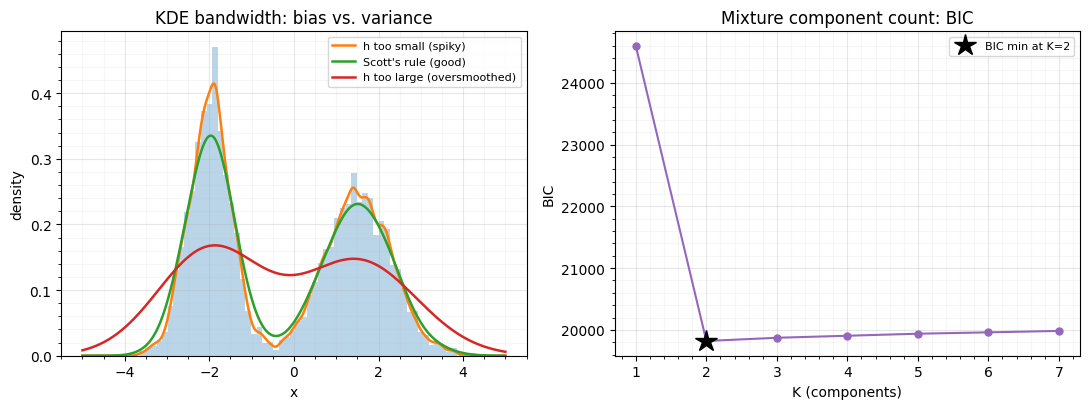

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for bw, label, c in [(0.05, "h too small (spiky)", "tab:orange"),
                     ("scott", "Scott's rule (good)", "tab:green"),
                     (0.6, "h too large (oversmoothed)", "tab:red")]:
    axes[0].plot(grid, stats.gaussian_kde(x[:, 0], bw_method=bw)(grid), lw=1.8,
                 label=label, color=c)
axes[0].hist(x[:, 0], bins=60, density=True, color="tab:blue", alpha=0.3)
axes[0].set(title="KDE bandwidth: bias vs. variance", xlabel="x", ylabel="density")
axes[0].legend(fontsize=8); style_ax(axes[0])

# Mixture: BIC selects K (penalised likelihood) on a held-out split.
Ks = np.arange(1, 8)
bic = [GaussianMixture(k, random_state=0).fit(x).bic(x) for k in Ks]
axes[1].plot(Ks, bic, "-o", color="tab:purple", ms=5)
axes[1].plot(Ks[np.argmin(bic)], min(bic), "k*", ms=16,
             label=f"BIC min at K={Ks[np.argmin(bic)]}")
axes[1].set(title="Mixture component count: BIC", xlabel="K (components)", ylabel="BIC")
axes[1].legend(fontsize=8); style_ax(axes[1])
fig.tight_layout()

print("BIC by K:", {int(k): round(v) for k, v in zip(Ks, bic)})

Left: the bandwidth sweep — the spiky orange curve would inject phantom wiggles
into the CDF (and noisy gradients), while the oversmoothed red one erases the
valley between modes. Right: **BIC** (log-likelihood penalised by parameter
count) bottoms out at $K=2$, the true number of modes — adding components past
that buys no likelihood worth the penalty. Cross-validated held-out likelihood
tells the same story.

## 4. The Jacobian — a smooth log-determinant

To use a marginal in a *flow* we need its per-coordinate **log-determinant**,
the gradient $T'(x)=\mathrm{d}z/\mathrm{d}x$ of $z=\Phi^{-1}(F(x))$:

$$
\frac{\mathrm{d}z}{\mathrm{d}x} = \frac{f(x)}{\varphi(z)},
\qquad
\log\big|T'(x)\big| = \log f(x) - \log\varphi(z),
\qquad
f(x) = \sum_k \pi_k\,\mathcal{N}(x;\mu_k,\sigma_k).
$$

Unlike the histogram's piecewise-constant $f$
([notebook 00](00_ecdf_histograms.ipynb)), the mixture density is **smooth**, so
the log-det is smooth and differentiable — what gradient training needs.
`gauss_flows.MixtureGaussianCDF.transform_and_log_det` returns exactly this
$\log|T'|$; we confirm it against an autodiff Jacobian.

log|T'| from transform_and_log_det vs autodiff: max|Δ| = 3.23e-15


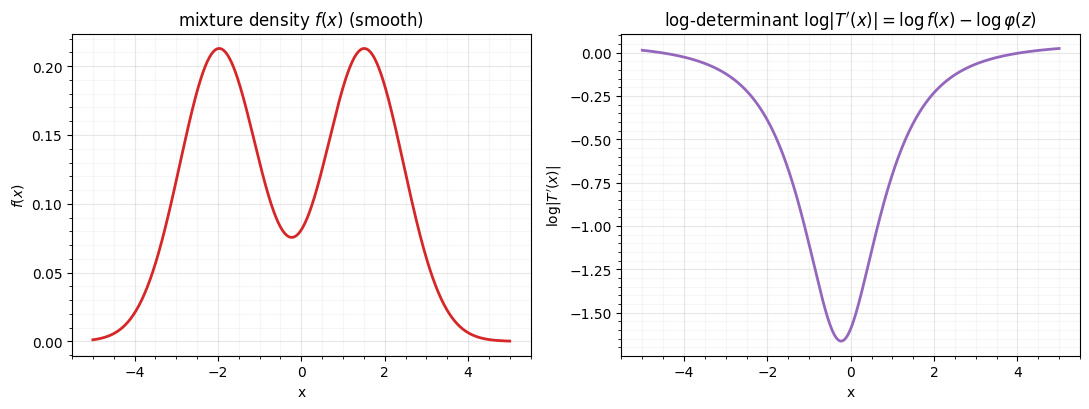

In [5]:
bj = gf.MixtureGaussianCDF.from_data(jnp.asarray(x), n_components=2)
xj = jnp.linspace(-5, 5, 600)[:, None]
zj, logdet = jax.vmap(bj.transform_and_log_det)(xj)
dzdx_auto = jax.vmap(lambda v: jax.jacfwd(bj.transform)(v).reshape(()))(xj)
f_mix = np.exp(np.asarray(logdet)) * stats.norm.pdf(np.asarray(zj).ravel())  # f = |T'|*phi(z)

print("log|T'| from transform_and_log_det vs autodiff: max|Δ| = "
      f"{float(jnp.max(jnp.abs(logdet - jnp.log(jnp.abs(dzdx_auto))))):.2e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(np.asarray(xj).ravel(), f_mix, color="tab:red", lw=2)
axes[0].set(title=r"mixture density $f(x)$ (smooth)", xlabel="x", ylabel="$f(x)$")
style_ax(axes[0])
axes[1].plot(np.asarray(xj).ravel(), np.asarray(logdet), color="tab:purple", lw=2)
axes[1].set(title=r"log-determinant $\log|T'(x)| = \log f(x) - \log\varphi(z)$",
            xlabel="x", ylabel=r"$\log|T'(x)|$")
style_ax(axes[1])
fig.tight_layout()

The package log-det matches autodiff to machine precision, and both are smooth
functions of $x$ — the low-density valley between the two modes is the central
dip in $\log|T'|$, which then rises toward the tails as $\varphi(z)\to 0$. This
smooth, exact log-det is precisely the per-coordinate term a flow sums in
`log_prob`.

## Recap

| estimator | CDF | knob | selector |
|---|---|---|---|
| KDE | sum of kernel CDFs (smooth) | bandwidth $h$ | Scott/Silverman, CV |
| Gaussian mixture | $\sum_k\pi_k\Phi$ (closed form) | components $K$ | BIC / held-out NLL |

| tool | role |
|---|---|
| `rbig.KDEGaussianizer` | nonparametric smooth marginal |
| `rbig.GMMGaussianizer` / `gf.MixtureGaussianCDF` | parametric marginal bijector |

**Next up.** Mixtures are smooth and compact but their inverse needs a
root-find. [02 — Monotone-spline CDFs](02_spline_cdf.ipynb) builds marginals
from monotone splines — including the rational-quadratic spline with an *exact*
analytic inverse, the bijector behind modern neural spline flows.